In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV 
# cross_validation is used to evaluate the performance of a model by splitting the data into multiple folds and training/testing the model on different combinations of these folds. GridSearchCV is used to perform hyperparameter tuning by exhaustively searching through a specified parameter grid.
from sklearn.pipeline import Pipeline
# Pipeline is a tool that allows you to chain together multiple steps of data preprocessing and modeling into a single object. It helps to streamline the workflow and ensures that the same transformations are applied consistently during both training and testing phases.
from sklearn.compose import ColumnTransformer
# ColumnTransformer is a tool that allows you to apply different preprocessing steps to different subsets of features in your dataset. It is particularly useful when you have a mix of numerical and categorical features, as it allows you to specify different transformations for each type of feature.
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# StandardScaler is a preprocessing technique that standardizes the features by removing the mean and scaling to unit variance. It is commonly used to ensure that all features are on the same scale, which can improve the performance of many machine learning algorithms. OneHotEncoder is a preprocessing technique that converts categorical variables into a format that can be provided to machine learning algorithms. It creates binary columns for each category in the original variable, allowing the model to understand and utilize the categorical information effectively.
from sklearn.impute import SimpleImputer
# SimpleImputer is a tool used to handle missing values in a dataset. It provides various strategies for imputing missing data, such as replacing missing values with the mean, median, or most frequent value of the respective feature. This helps to ensure that the dataset is complete and can be used effectively for training machine learning models.
from sklearn.linear_model import LinearRegression, Ridge, Lasso
# LinearRegression is a linear model that estimates the relationship between a dependent variable and one or more independent variables by fitting a linear equation to the observed data. Ridge and Lasso are regularization techniques that add a penalty term to the linear regression cost function to prevent overfitting. Ridge regression adds an L2 penalty, while Lasso regression adds an L1 penalty, which can lead to feature selection by shrinking some coefficients to zero.
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
# RandomForestRegressor is an ensemble learning method that combines multiple decision trees to improve the predictive performance and reduce overfitting. It works by creating a large number of decision trees during training and outputting the average prediction of the individual trees for regression tasks. HistGradientBoostingRegressor is a gradient boosting algorithm that builds an ensemble of decision trees in a sequential manner, where each tree is trained to correct the errors of the previous trees. It uses histogram-based techniques to speed up the training process and can handle large datasets efficiently.
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

In [23]:
# configurations
# set pandas display options for better readability of dataframes. The "display.max_columns" option is set to None to show all columns in the dataframe, and the "display.float_format" option is set to format floating-point numbers to three decimal places. The seaborn theme is set to "darkgrid" for better visualization of plots. Additionally, the matplotlib parameters are updated to specify the font sizes for axes titles, labels, and tick labels for improved readability of plots.
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})
# define constants for the project. RANDOM_STATE is set to 42 to ensure reproducibility of results. CSV_PATH is set to "housing.csv", which is the path to the dataset being used. TARGET_COL is set to "median_house_value", which is the name of the target column in the dataset that we want to predict.
RANDOM_STATE = 42
CSV_PATH = "housing_dataset.csv"          # update path for a different dataset
TARGET_COL = "median_house_value" # target column name

In [24]:
df = pd.read_csv(CSV_PATH)

In [25]:
print("DataFrame shape:", df.shape)


DataFrame shape: (20640, 10)


In [26]:

df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY


In [27]:
# eda means exploratory data analysis. It is the process of analyzing and summarizing a dataset to understand its main characteristics, often using visual methods. EDA helps to uncover patterns, detect anomalies, test hypotheses, and check assumptions with the help of summary statistics and graphical representations.
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [29]:
# to identify numerical and categorical columns in the dataframe. The select_dtypes method is used to select columns based on their data types. The include parameter is set to [np.number] to select numerical columns and ["object"] to select categorical columns. The resulting column names are stored in the num_cols and cat_cols lists, respectively.
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Target column:", TARGET_COL)
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Target column: median_house_value
Numerical columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical columns: ['ocean_proximity']


/var/folders/6k/pfntd1rx6gn4z_rqr5zn94y80000gn/T/ipykernel_32691/3024758816.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [30]:
# missing values analysis to check for missing values in the dataframe. The isna() method is used to identify missing values, and the sum() method is applied to count the number of missing values in each column. The result is printed to show the number of missing values per column.
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [31]:
# check presence of encoded missing values in categorical columns. The value_counts() method is used to count the occurrences of each unique value in the categorical columns, and the head(20) method is applied to display the top 20 most frequent values for each column. This helps to identify any encoded missing values that may be present in the categorical data.
for col in df.columns:
    print(df[col].value_counts().head(20)) 

longitude
-118.310    162
-118.300    160
-118.290    148
-118.270    144
-118.320    142
-118.280    141
-118.350    140
-118.360    138
-118.190    135
-118.370    128
-118.250    128
-118.200    126
-118.140    125
-118.260    121
-118.130    121
-118.180    120
-118.340    119
-118.210    118
-118.150    116
-118.120    112
Name: count, dtype: int64
latitude
34.060    244
34.050    236
34.080    234
34.070    231
34.040    221
34.090    212
34.020    208
34.100    203
34.030    193
33.930    181
33.940    175
33.970    172
33.990    168
33.880    164
34.110    162
33.980    162
34.160    159
34.120    158
34.150    157
34.010    156
Name: count, dtype: int64
housing_median_age
52.000    1273
36.000     862
35.000     824
16.000     771
17.000     698
34.000     689
26.000     619
33.000     615
18.000     570
25.000     566
32.000     565
37.000     537
15.000     512
19.000     502
27.000     488
24.000     478
30.000     476
28.000     471
20.000     465
29.000     461
Name: coun

In [32]:
# duplicates analysis to check for duplicate rows in the dataframe. The duplicated() method is used to create a boolean mask that identifies duplicate rows, and the sum() method is applied to count the number of duplicate rows. The result is printed to show the total number of duplicate rows in the dataset.
# if there are duplicate rows, you may want to consider removing them using the drop_duplicates() method to ensure that your analysis and modeling are not biased by repeated data points.
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

Number of duplicate rows: 0


In [33]:
# descriptive statistics for numerical columns in the dataframe. The describe() method is used to generate summary statistics for the numerical columns, including count, mean, standard deviation, minimum, 25th percentile, median (50th percentile), 75th percentile, and maximum values. This provides insights into the distribution and central tendency of the numerical features in the dataset.
df[num_cols].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000,20640.000,20640.000,20640.000,20433.000,20640.000,20640.000,20640.000,20640.000
mean,-119.570,35.632,28.639,2635.763,537.871,1425.477,499.540,3.871,206855.817
std,2.004,2.136,12.586,2181.615,421.385,1132.462,382.330,1.900,115395.616
min,-124.350,32.540,1.000,2.000,1.000,3.000,1.000,0.500,14999.000
25%,-121.800,33.930,18.000,1447.750,296.000,787.000,280.000,2.563,119600.000
50%,-118.490,34.260,29.000,2127.000,435.000,1166.000,409.000,3.535,179700.000
75%,-118.010,37.710,37.000,3148.000,647.000,1725.000,605.000,4.743,264725.000
max,-114.310,41.950,52.000,39320.000,6445.000,35682.000,6082.000,15.000,500001.000


In [34]:
# descriptive stats for numerical columns with transposed output for better readability. The describe() method is used to generate summary statistics for the numerical columns, and the T attribute is applied to transpose the output, making it easier to read and compare the statistics for each column.
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.000,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
latitude,20640.000,35.632,2.136,32.540,33.930,34.260,37.710,41.950
housing_median_age,20640.000,28.639,12.586,1.000,18.000,29.000,37.000,52.000
total_rooms,20640.000,2635.763,2181.615,2.000,1447.750,2127.000,3148.000,39320.000
total_bedrooms,20433.000,537.871,421.385,1.000,296.000,435.000,647.000,6445.000
population,20640.000,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
households,20640.000,499.540,382.330,1.000,280.000,409.000,605.000,6082.000
median_income,20640.000,3.871,1.900,0.500,2.563,3.535,4.743,15.000
median_house_value,20640.000,206855.817,115395.616,14999.000,119600.000,179700.000,264725.000,500001.000


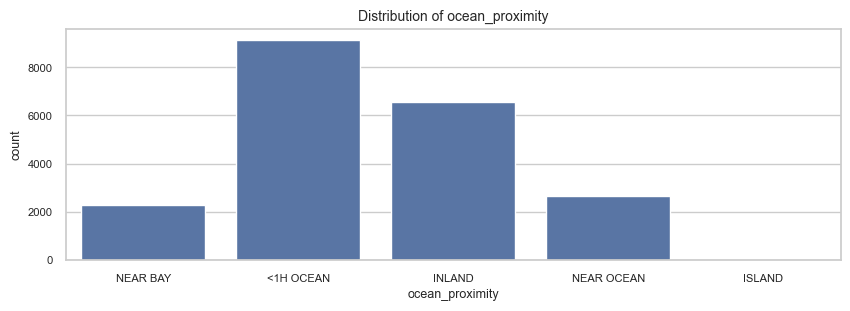

In [35]:
# countplot for categorical columns to visualize the distribution of categorical variables in the dataset. The countplot function from seaborn is used to create bar plots for each categorical column, showing the count of occurrences for each category. The figure size is set to (10, 3) for better visibility, and the title of each plot is set to indicate the distribution of the respective categorical column.
for col in cat_cols:
    plt.figure(figsize=(10, 3))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

In [36]:
for col in cat_cols:
    print(df[col].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


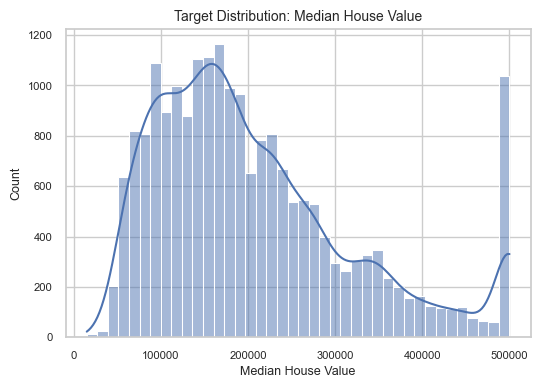

In [37]:
# target column distribution to visualize the distribution of the target variable, which is "median_house_value" in this case. The histplot function from seaborn is used to create a histogram with a kernel density estimate (KDE) overlay. The figure size is set to (6, 4) for better visibility, and the title and x-axis label are set to indicate the distribution of the target variable.
plt.figure(figsize=(6,4))
sns.histplot(df[TARGET_COL], bins=40, kde=True)
plt.title("Target Distribution: Median House Value")
plt.xlabel("Median House Value")
plt.show()

In [38]:
df[TARGET_COL].value_counts()

median_house_value
500001.000    965
137500.000    122
162500.000    117
112500.000    103
187500.000     93
             ... 
422900.000      1
349400.000      1
425800.000      1
200700.000      1
47000.000       1
Name: count, Length: 3842, dtype: int64

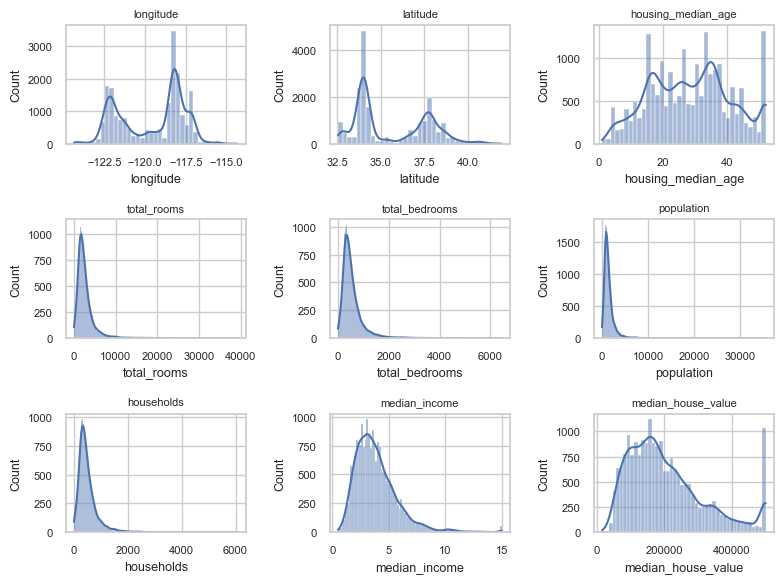

In [39]:
# histogram plot - distribution of numerical columns in the dataframe. The subplots function from matplotlib is used to create a grid of plots, and the histplot function from seaborn is used to create histograms with KDE overlays for each numerical column. The figure size is set to (8, 6) for better visibility, and the title of each plot is set to indicate the respective numerical column being visualized. The tight_layout function is called to adjust the spacing between the plots, and the show function is used to display the plots.
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

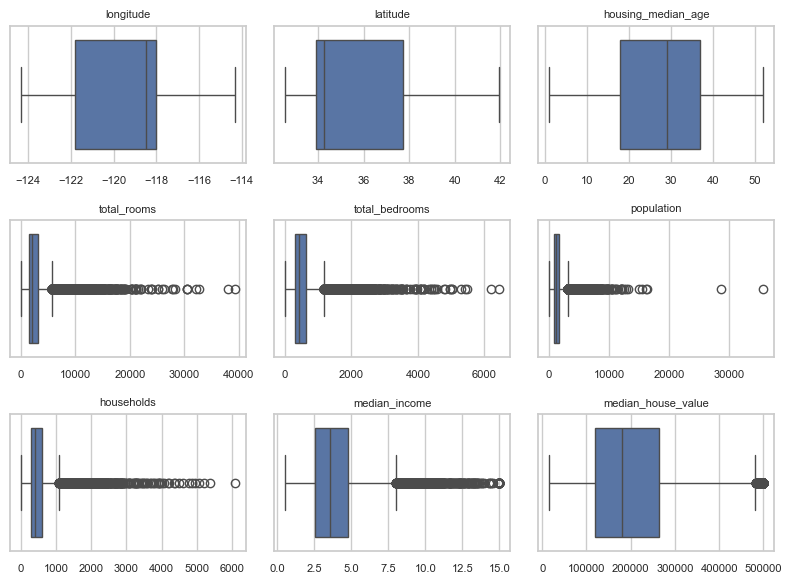

In [40]:
# outliers analysis - boxplot to visualize the distribution of numerical columns and identify potential outliers in the dataset. The subplots function from matplotlib is used to create a grid of plots, and the boxplot function from seaborn is used to create box plots for each numerical column. The figure size is set to (8, 6) for better visibility, and the title of each plot is set to indicate the respective numerical column being visualized. The tight_layout function is called to adjust the spacing between the plots, and the show function is used to display the plots. Box plots are useful for identifying outliers, as they display the median, quartiles, and potential outliers in the data.
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

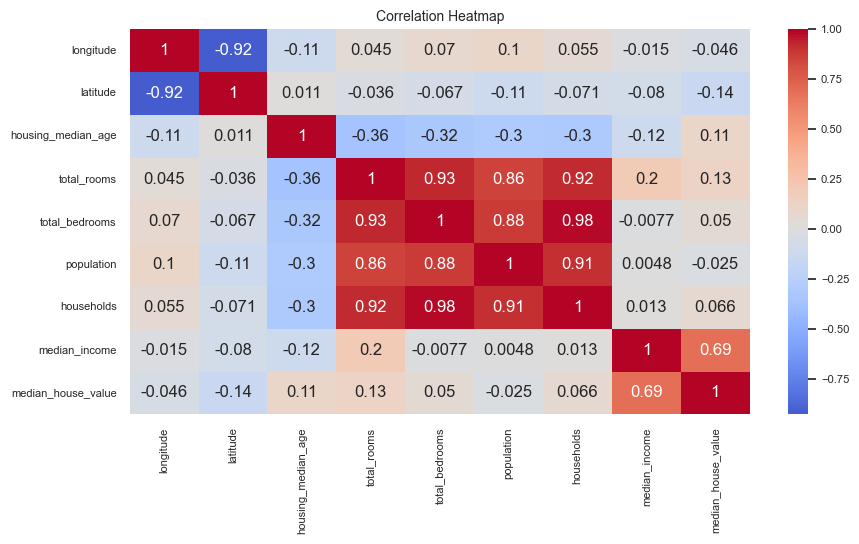

In [41]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(10, 5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

In [42]:
# Correlation with target
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("\nCorrelation with target:")
print(corr_with_target)


Correlation with target:
median_house_value    1.000
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


🔍 Key Insights from EDA

Dataset has numeric + one categorical feature (ocean_proximity)
Only total_bedrooms has missing values
Target (median_house_value) is right-skewed and capped
#right - skewed and capped and outliners means 
Several features show strong skew and outliers
median_income is the strongest predictor
High multicollinearity among room and population features
⸻

🛠️ Preprocessing & Evaluation Plan

Median imputation for missing values
One-hot encoding for categorical feature
Feature scaling for linear models
Use pipelines to avoid data leakage
Baseline model → CV model selection → hyperparameter tuning
Primary metric: RMSE, secondary: MAE and R²
Final evaluation only on test set

4. Data Preprocessing

In [43]:
# separate features and target variables for modeling. The drop() method is used to create a new dataframe X that contains all columns except the target column, while the target variable y is created by selecting the target column from the original dataframe. This separation allows us to use X as the input features for training machine learning models and y as the output variable we want to predict.
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [44]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,NEAR BAY


In [45]:
y.head()

0   452600.000
1   358500.000
2   352100.000
3   341300.000
4   342200.000
Name: median_house_value, dtype: float64

In [46]:
# train test split to split the dataset into training and testing sets. The train_test_split function from scikit-learn is used to randomly split the features (X) and target variable (y) into training and testing sets. The test_size parameter is set to 0.2, which means that 20% of the data will be used for testing, while the remaining 80% will be used for training. The random_state parameter is set to a constant value (RANDOM_STATE) to ensure reproducibility of the results. The resulting X_train, X_test, y_train, and y_test variables contain the respective training and testing data for features and target variable.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [48]:
print("Train shape:", X_train.shape)

print("Test shape:", X_test.shape)

Train shape: (16512, 9)
Test shape: (4128, 9)


Preprocessing Pipeline

In [50]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

# numerical features - preprocessing steps
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# categorical features - preprocessing steps
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# preprocessing pipeline to apply the respective transformations to numerical and categorical features. The ColumnTransformer is used to specify the transformations for each type of feature. The "num" transformer applies the numerical_transformer pipeline to the numerical_features, while the "cat" transformer applies the categorical_transformer pipeline to the categorical_features. This allows for a streamlined and consistent preprocessing workflow for both types of features in the dataset.
preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numerical features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical features: ['ocean_proximity']


5. Baseline model (No CV, No Tuning)

In [52]:
# create a machine learning pipeline that combines the preprocessing steps with a linear regression model. The Pipeline is used to chain together the preprocessing steps defined in the preprocess variable and the LinearRegression model. This allows for a streamlined workflow where the data is first preprocessed according to the specified transformations, and then the linear regression model is applied to the preprocessed data for training and prediction.
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

In [54]:
# preprocess the data and train the baseline model using the fit() method of the pipeline. The fit() method takes the training features (X_train) and the training target variable (y_train) as input, applies the specified preprocessing steps to the features, and then fits the linear regression model to the preprocessed data. This step is crucial for training the model and preparing it for making predictions on new data.
baseline_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

Evaluation of baseline model

In [56]:
train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)

In [58]:
# display the first 5 predictions of the baseline model on the training data. The predict() method of the pipeline is used to generate predictions for the training features (X_train), and the resulting predictions are stored in the train_baseline_pred variable. The first 5 predictions are then printed to provide a glimpse of the model's output on the training data.
train_baseline_pred[:5]


array([188628.0772436 , 290379.8948687 , 250985.48476349, 146878.07878194,
       165789.41368924])

In [60]:
y_train[:5]

14196   103000.000
8267    382100.000
17445   172600.000
14265    93400.000
2271     96500.000
Name: median_house_value, dtype: float64

In [62]:
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("\n=== TRAIN BASELINE METRICS (LinearRegression) ===")
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"MAE : {train_baseline_mae:.3f}")
print(f"R2  : {train_baseline_r2:.3f}")


=== TRAIN BASELINE METRICS (LinearRegression) ===
RMSE: 68433.937
MAE : 49594.842
R2  : 0.650


In [64]:
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("\n=== TEST BASELINE METRICS (LinearRegression) ===")
print(f"RMSE: {test_baseline_rmse:.3f}")
print(f"MAE : {test_baseline_mae:.3f}")
print(f"R2  : {test_baseline_r2:.3f}")


=== TEST BASELINE METRICS (LinearRegression) ===
RMSE: 70059.193
MAE : 50670.489
R2  : 0.625



6. Model Selection & Optimization

In [ ]:
# models to try  - a dictionary of machine learning models that we want to try for our regression task. The keys of the dictionary are the names of the models, and the values are instances of the respective model classes from scikit-learn. This allows us to easily iterate through the models and evaluate their performance on the dataset. 
# line
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=10000),
    "RandomForest": RandomForestRegressor(),
    "HistGB": HistGradientBoostingRegressor()
}

In [69]:
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [71]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

In [73]:
rows = []

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({
        "model": name,
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_mae": -scores["test_mae"].mean(),
        "cv_r2": scores["test_r2"].mean()        
    })


# sort based on lowest rmse value
cv_results = pd.DataFrame(rows).sort_values("cv_rmse")
print("=== CV Model Comparison ===")
print(cv_results)

=== CV Model Comparison ===
              model   cv_rmse    cv_mae  cv_r2
4            HistGB 48126.259 32230.219  0.827
3      RandomForest 49327.392 32219.461  0.818
1             Ridge 68595.617 49664.331  0.648
2             Lasso 68603.233 49667.263  0.648
0  LinearRegression 68604.163 49667.159  0.648


In [75]:
cv_results

,model,cv_rmse,cv_mae,cv_r2
4,HistGB,48126.259,32230.219,0.827
3,RandomForest,49327.392,32219.461,0.818
1,Ridge,68595.617,49664.331,0.648
2,Lasso,68603.233,49667.263,0.648
0,LinearRegression,68604.163,49667.159,0.648


In [77]:
best_row = cv_results.sort_values("cv_rmse").iloc[0]

best_model_name = best_row["model"]
best_rmse = best_row["cv_rmse"]

print("Best model based on CV RMSE:")
print("Model :", best_model_name)
print("CV RMSE:", best_rmse)

Best model based on CV RMSE:
Model : HistGB
CV RMSE: 48126.259346697436


7. Hyperparameter Tuning

In [79]:
hgb_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))
    ]
)

In [81]:
# hyperparameters combination to try for the HistGradientBoostingRegressor model. The param_grid dictionary specifies the hyperparameters and their respective values that we want to explore during the grid search process. The keys of the dictionary correspond to the hyperparameters of the model, prefixed with "model__" to indicate that they belong to the model step in the pipeline. The values are lists of potential values for each hyperparameter, allowing us to systematically evaluate different combinations and find the optimal set of hyperparameters for our model.
param_grid = {
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [None, 3, 6],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [20, 50, 100],
    "model__l2_regularization": [0.0, 0.1, 1.0]
}

In [82]:
grid = GridSearchCV(
    estimator=hgb_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

In [84]:
# perform grid search
grid.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__l2_regularization': [0.0, 0.1, ...], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [None, 3, ...], 'model__max_leaf_nodes': [15, 31, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls 

In [86]:
print("\n=== TUNED HistGB (CV) ===")
print("Best CV RMSE:", -grid.best_score_)
print("Best params:", grid.best_params_)


=== TUNED HistGB (CV) ===
Best CV RMSE: 47408.35933729127
Best params: {'model__l2_regularization': 0.1, 'model__learning_rate': 0.1, 'model__max_depth': None, 'model__max_leaf_nodes': 63, 'model__min_samples_leaf': 20}


8. Retraining with best params

In [87]:
hgb_best = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(
            l2_regularization=0.1,
            learning_rate=0.1,
            max_depth=None,
            max_leaf_nodes=63,
            min_samples_leaf=20
        ))
    ]
)

In [89]:
# train best model on entire training data (can also be done with refit=True in grid search)
hgb_best.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

9. Final Evaluation

In [91]:
train_final_pred = hgb_best.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("\n=== FINAL MODEL (Tuned HGB) Train Performance ===")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"MAE : {train_final_mae:.3f}")
print(f"R2  : {train_final_r2:.3f}")


=== FINAL MODEL (Tuned HGB) Train Performance ===
RMSE: 35836.213
MAE : 24372.655
R2  : 0.904


In [93]:
test_final_pred = hgb_best.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("\n=== FINAL MODEL (Tuned HGB) Test Performance ===")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"MAE : {test_final_mae:.3f}")
print(f"R2  : {test_final_r2:.3f}")


=== FINAL MODEL (Tuned HGB) Test Performance ===
RMSE: 46305.629
MAE : 30690.199
R2  : 0.836


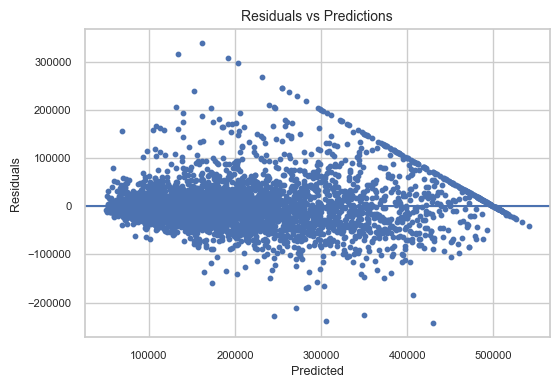

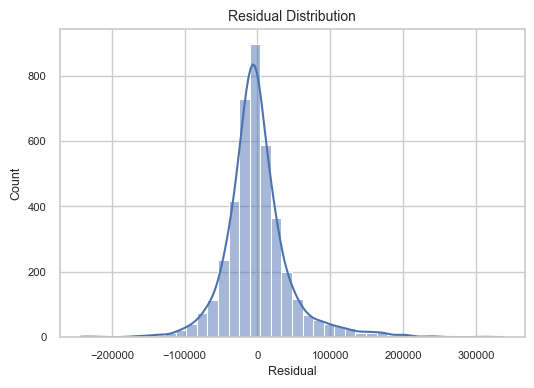

In [94]:
# residual plot
residuals = y_test - test_final_pred

plt.figure(figsize=(6, 4))
plt.scatter(test_final_pred, residuals, s=10)
plt.axhline(0)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

In [98]:
# save model
import joblib
joblib.dump(hgb_best, "model.pkl")

['model.pkl']

10. Building a predictive system

In [96]:
def predict_house_price(
    model,
    longitude: float,
    latitude: float,
    housing_median_age: float,
    total_rooms: float,
    total_bedrooms: float,
    population: float,
    households: float,
    median_income: float,
    ocean_proximity: str
) -> float:
    """
    Predict median_house_value for one new house.
    total_bedrooms can be np.nan (pipeline will impute).
    """
    new_row = pd.DataFrame([{
        "longitude": longitude,
        "latitude": latitude,
        "housing_median_age": housing_median_age,
        "total_rooms": total_rooms,
        "total_bedrooms": total_bedrooms,
        "population": population,
        "households": households,
        "median_income": median_income,
        "ocean_proximity": ocean_proximity
    }])

    return float(model.predict(new_row)[0])

In [97]:
price = predict_house_price(
    model=hgb_best,
    longitude=-122.23,
    latitude=37.88,
    housing_median_age=41,
    total_rooms=880,
    total_bedrooms=129,
    population=322,
    households=126,
    median_income=8.3252,
    ocean_proximity="NEAR BAY"
)

print("Predicted House Price:", price)

Predicted House Price: 449544.3412507278
